# Continuation Power Flow

Standard power flow computes the operating point at a given loading level, but it cannot determine how far the system is from voltage collapse. Continuation power flow (CPF) answers this question by tracing the relationship between loading and bus voltages, known as the *nose curve* or *PV curve*, from the base case up to and beyond the maximum loadability point.

The CPF uses a predictor-corrector method with a continuation parameter $\lambda$ that interpolates between the base case ($\lambda=0$) and a target loading condition ($\lambda=1$):

$$p(\lambda) = p_{\text{base}} + \lambda \cdot (p_{\text{target}} - p_{\text{base}})$$

At each step, a tangent predictor estimates the next point on the curve, and an augmented Newton-Raphson corrector refines it. The maximum $\lambda$ achieved gives the steady-state loadability limit, the point beyond which no power flow solution exists.

This tutorial covers running CPF in ANDES, interpreting results, plotting PV curves, QV curve analysis for reactive power margins, selecting parameterization methods, and specifying custom loading targets.

In [1]:
%matplotlib inline

# Reduce logging verbosity for PDF builds
import os
if os.environ.get('SPHINX_BUILD_PDF'):
    import andes
    _orig_config_logger = andes.config_logger
    def _quiet_logger(stream_level=20, *args, **kwargs):
        stream_level = max(stream_level, 30)
        return _orig_config_logger(stream_level, *args, **kwargs)
    andes.config_logger = _quiet_logger

## Setup

CPF requires a converged power flow as its starting point. We load the IEEE 14-bus system and run power flow first.

In [2]:
import numpy as np
import andes
from matplotlib import pyplot as plt

andes.config_logger(stream_level=20)

In [3]:
ss = andes.load(andes.get_case('ieee14/ieee14.json'))
ss.PFlow.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Loaded generated Python code in "/home/hcui9/.andes/pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0017 seconds.
Connectivity check completed in 0.0001 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0106 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.2323 seconds.
Numba compilation for power flow finished in 0.2736 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0019 seconds.
Report saved to "ieee14_out.txt" in 0.0005 seco

True

## Running CPF

The simplest way to run CPF is to specify a uniform load scaling factor. A `load_scale` of 2.0 means the target loading is twice the base case: all PQ loads and PV generation are scaled proportionally. The CPF traces the nose curve from $\lambda=0$ (base case) toward $\lambda=1$ (target), and beyond if the system can sustain it.

In [4]:
ss.CPF.run(load_scale=2.0)


-> Continuation Power Flow
Parameterization: pseudo_arclength
       Step size: 0.1
   Adaptive step: On
         Stop at: NOSE
Nose detected at step 16, lambda=3.167739

-> CPF Report
       Converged: True
           Steps: 17
      Max lambda: 3.258046
     Termination: Nose point at lambda=3.258046
CPF completed in 17 steps in 0.0175 seconds. max lambda = 3.258046


True

The CPF report shows the number of continuation steps, the maximum $\lambda$ reached (the loadability limit), and the termination reason. A `max_lam` greater than 1.0 means the system can sustain the full target loading; the nose point occurs at some higher loading level.

The `run()` method returns `True` if the CPF terminated as expected for the requested `stop_at` mode:

- `stop_at='NOSE'` (default): terminates at the nose point (maximum loadability)
- `stop_at='FULL'`: traces both the upper and lower branches, returning to $\lambda=0$
- `stop_at=float`: terminates when $\lambda$ reaches the specified value

The key results are stored as NumPy arrays:

| Attribute | Shape | Description |
|-----------|-------|-------------|
| `ss.CPF.lam` | `(npoints,)` | Continuation parameter $\lambda$ at each step |
| `ss.CPF.V` | `(nbus, npoints)` | Bus voltage magnitudes at each step |
| `ss.CPF.theta` | `(nbus, npoints)` | Bus voltage angles at each step |
| `ss.CPF.max_lam` | scalar | Maximum $\lambda$ (loadability limit) |
| `ss.CPF.steps` | `(npoints-1,)` | Step sizes used at each continuation step |

In [5]:
ss.CPF.max_lam

3.258045861221937

## Plotting the Nose Curve

The PV curve reveals how bus voltages change with loading. Weak buses, those with the steepest voltage decline, are the most vulnerable to voltage collapse. The built-in `plot()` method creates a PV curve for a specified bus, with the nose point marked.

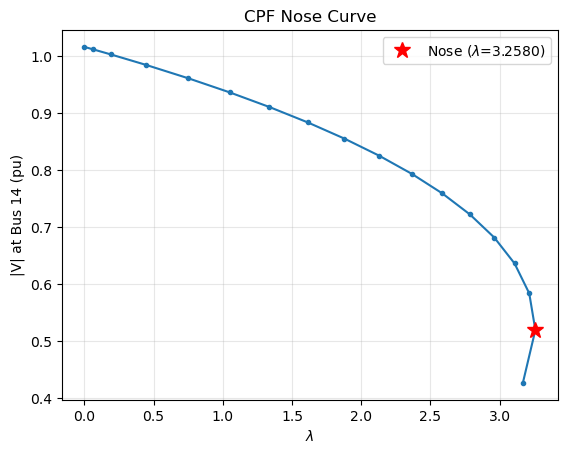

In [6]:
fig, ax = ss.CPF.plot(bus_idx=14, show=False)
plt.show()

The `V`, `lam`, and `theta` arrays can be used directly for custom analysis. The following example extracts the nose-point data, identifies the weakest bus, and plots a publication-quality PV curve.

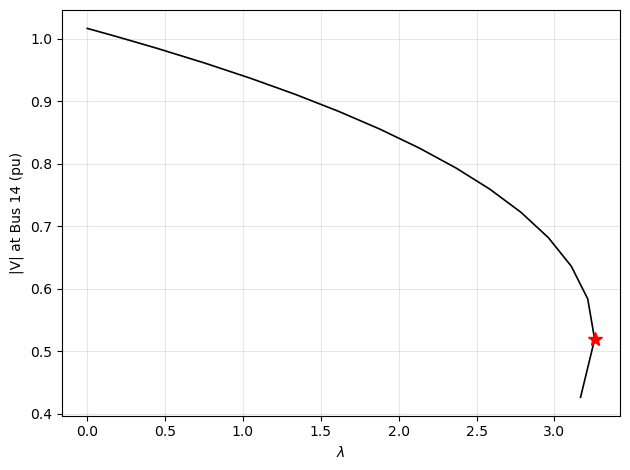

In [7]:
lam = ss.CPF.lam
nose = np.argmax(lam)

# Weakest bus = largest voltage drop from base to nose.
weak = np.argmax(ss.CPF.V[:, 0] - ss.CPF.V[:, nose])

fig, ax = plt.subplots()
ax.plot(lam, ss.CPF.V[weak, :], 'k-', linewidth=1.2)
ax.plot(lam[nose], ss.CPF.V[weak, nose], 'r*', markersize=10)
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(f'|V| at Bus {ss.Bus.idx.v[weak]} (pu)')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

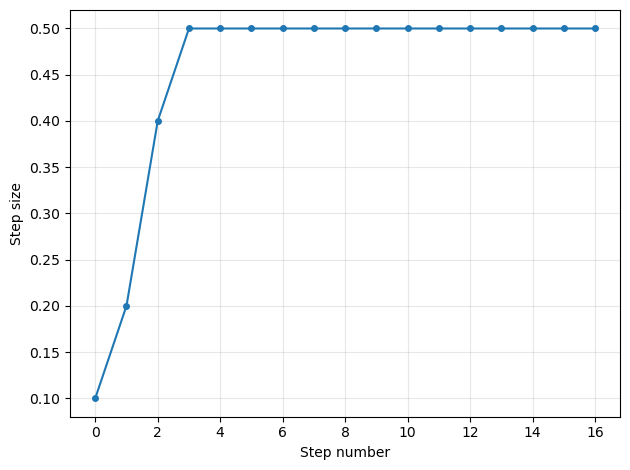

In [8]:
fig, ax = plt.subplots()
ax.plot(range(len(ss.CPF.steps)), ss.CPF.steps, 'o-', markersize=4)
ax.set_xlabel('Step number')
ax.set_ylabel('Step size')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Parameterization Methods

The parameterization determines how the corrector constrains the solution at each step. Different methods have different trade-offs near the nose point, where the standard power flow Jacobian becomes singular.

ANDES provides three parameterization methods:

| Method | Description | Behavior at nose |
|--------|-------------|------------------|
| `pseudo_arclength` | Constrains the step along the tangent direction | Most robust; can trace through the nose point |
| `arclength` | Constrains the Euclidean distance from the previous point | Traces the full curve; may take more steps |
| `natural` | Fixes $\lambda$ increment directly | Simplest; fails at the nose point |

Pseudo arc-length is the default because it handles the nose point most reliably. Natural parameterization is the simplest conceptually but becomes singular exactly at the loadability limit, making it unable to trace the lower branch of the PV curve.

The parameterization is selected through the configuration before running CPF.

In [9]:
# reload to get a fresh system
ss2 = andes.load(andes.get_case('ieee14/ieee14.json'))
ss2.PFlow.run()

ss2.CPF.config.parameterization = 'arclength'
ss2.CPF.run(load_scale=2.0)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0010 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0097 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0033 seconds.
Numba compilation for power flow finished in 0.0192 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0009 seconds.
Report saved to "ieee14_out.txt" in 0.0004 seconds.

-> C

True

In [10]:
ss2.CPF.max_lam

3.2580499020258316

All three methods should agree on the loadability limit to within a few percent, since they trace the same underlying curve. The differences arise from how finely they sample the curve near the nose.

## Termination Control

By default, CPF terminates at the nose point (`stop_at='NOSE'`). In some analyses, it is useful to stop at a specific loading level instead, for example, to find the voltage profile at 1.5 times the base-case loading. Setting `stop_at` to a float value causes CPF to terminate when $\lambda$ reaches that value, with the final step sized to land exactly on the target.

In [11]:
ss3 = andes.load(andes.get_case('ieee14/ieee14.json'))
ss3.PFlow.run()

ss3.CPF.config.stop_at = 1.5
ss3.CPF.run(load_scale=2.0)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0011 seconds.
Connectivity check completed in 0.0001 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0103 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0034 seconds.
Numba compilation for power flow finished in 0.0212 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0010 seconds.
Report saved to "ieee14_out.txt" in 0.0003 seconds.

-> C

True

In [12]:
ss3.CPF.lam[-1]

np.float64(1.5)

The final $\lambda$ value is exactly the requested target (to within solver tolerance).

## Full Curve Tracing (Upper and Lower Branches)

Setting `stop_at='FULL'` traces the complete nose curve: the upper branch from $\lambda=0$ to the nose, then the lower (unstable) branch back down to $\lambda=0$. At the nose point, the continuation detects the fold bifurcation and automatically switches to the lower branch. The lower branch represents unstable equilibrium points that are physically unrealizable but are important for voltage stability analysis.

The lower branch voltages are significantly below the upper branch at the same loading level. At $\lambda=0$ on the lower branch, the bus voltages represent the low-voltage solution of the base-case power flow equations.

In [13]:
ss_full = andes.load(andes.get_case('ieee14/ieee14.json'))
ss_full.PFlow.run()

ss_full.CPF.config.stop_at = 'FULL'
ss_full.CPF.run(load_scale=2.0)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0010 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0099 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0034 seconds.
Numba compilation for power flow finished in 0.0209 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0010 seconds.
Report saved to "ieee14_out.txt" in 0.0004 seconds.

-> C

True

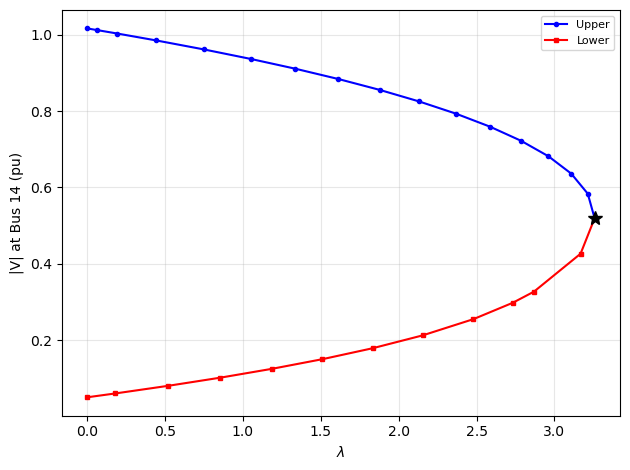

In [14]:
lam = ss_full.CPF.lam
nose = np.argmax(lam)
weak = np.argmax(ss_full.CPF.V[:, 0] - ss_full.CPF.V[:, nose])

fig, ax = plt.subplots()
ax.plot(lam[:nose+1], ss_full.CPF.V[weak, :nose+1], 'b-o', markersize=3, label='Upper')
ax.plot(lam[nose:], ss_full.CPF.V[weak, nose:], 'r-s', markersize=3, label='Lower')
ax.plot(lam[nose], ss_full.CPF.V[weak, nose], 'k*', markersize=10)
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(f'|V| at Bus {ss_full.Bus.idx.v[weak]} (pu)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Per-Device Loading Targets

Uniform load scaling is the most common use case, but real planning studies often involve non-uniform load growth. For example, one area may grow faster than another. The `p0_target` and `q0_target` arguments accept per-device arrays that specify the target active and reactive power for each PQ load. Similarly, `pg_target` specifies the target generation for each PV generator.

The continuation parameter $\lambda$ then interpolates between the base-case values and these per-device targets.

In [15]:
ss4 = andes.load(andes.get_case('ieee14/ieee14.json'))
ss4.PFlow.run()

# Double the load on the first 5 PQ buses, keep the rest unchanged
p0_base = ss4.PQ.p0.v.copy()
q0_base = ss4.PQ.q0.v.copy()

p0_target = p0_base.copy()
q0_target = q0_base.copy()
p0_target[:5] = p0_base[:5] * 3.0
q0_target[:5] = q0_base[:5] * 3.0

ss4.CPF.run(p0_target=p0_target, q0_target=q0_target)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...


Input file parsed in 0.0015 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0104 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0034 seconds.
Numba compilation for power flow finished in 0.0205 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0010 seconds.
Report saved to "ieee14_out.txt" in 0.0003 seconds.

-> Continuation Power Flow
Parameterization: pseudo_arclength
       Step size: 0.1
   Adaptive step: On
         Stop at: NOSE
Nose detected at step 56, lambda=3.516561

-> CPF Report
       Converged: True
           Steps: 57
      Max lambda: 3.517463
   

True

In [16]:
ss4.CPF.max_lam

3.5174627656342903

## QV Curve Analysis

A QV curve shows the reactive power required to maintain a given voltage at a specific bus. The nose of the QV curve gives the reactive power margin, the additional reactive power absorption the bus can sustain before voltage collapse. While the PV curve parameterizes active power, the QV curve fixes active power everywhere and varies only reactive power at the target bus.

The `run_qv()` method builds the appropriate continuation target internally and delegates to the CPF engine. The `q_range` argument specifies the total reactive power sweep range in per-unit on the system base.

In [17]:
ss_qv = andes.load(andes.get_case('ieee14/ieee14.json'))
ss_qv.PFlow.run()

ss_qv.CPF.run_qv(bus_idx=14, q_range=3.0)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0011 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0098 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0032 seconds.
Numba compilation for power flow finished in 0.0231 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0010 seconds.
Report saved to "ieee14_out.txt" in 0.0004 seconds.

-> C

True

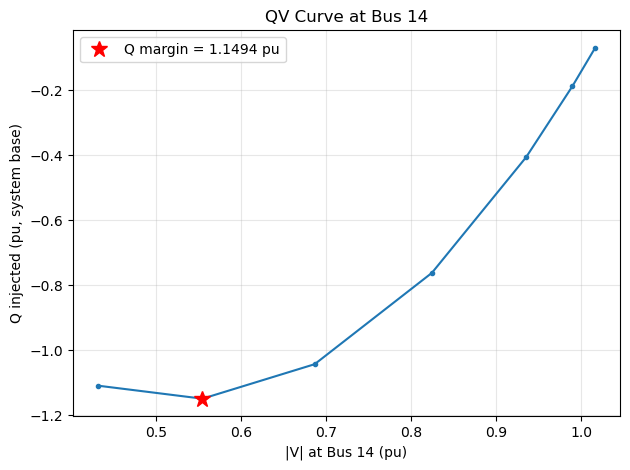

In [18]:
fig, ax = ss_qv.CPF.plot_qv(show=False)
fig.tight_layout()
plt.show()

The QV curve results are stored in `qv_q` (reactive power in load convention) and `qv_v` (voltage magnitude), both 1-D arrays aligned with `lam`. The `plot_qv()` method negates `qv_q` to follow the standard convention where positive Q represents injection (capacitive support). The red star marks the nose point, which indicates the maximum reactive power that can be absorbed at the bus before voltage collapse.

## Configuration

The CPF routine provides several configuration options accessible through `ss.CPF.config`.

In [19]:
ss.CPF.config

OrderedDict([('linsolve', 0),
             ('parameterization', 'pseudo_arclength'),
             ('step', 0.1),
             ('step_min', 0.0001),
             ('step_max', 0.5),
             ('adapt_step', 1),
             ('tol', 1e-06),
             ('max_iter', 20),
             ('max_steps', 500),
             ('stop_at', 'NOSE'),
             ('report', 1)])

| Option | Default | Description |
|--------|---------|-------------|
| `parameterization` | `pseudo_arclength` | Continuation method: `pseudo_arclength`, `arclength`, or `natural` |
| `step` | 0.1 | Initial step size for the continuation parameter |
| `step_min` | 1e-4 | Minimum step size before declaring convergence failure |
| `step_max` | 0.5 | Maximum step size (limits adaptive growth) |
| `adapt_step` | 1 | Enable adaptive step sizing (grow on easy steps, shrink on hard) |
| `tol` | 1e-6 | Convergence tolerance for the augmented NR corrector |
| `max_iter` | 20 | Maximum Newton-Raphson iterations per corrector step |
| `max_steps` | 500 | Maximum number of continuation steps |
| `stop_at` | `NOSE` | Termination: `'NOSE'`, `'FULL'` (trace lower branch), or a float $\lambda$ |
| `report` | 1 | Print summary report after completion |

Reactive power limits are enforced through the PV model's built-in PV-to-PQ conversion. Pass `config_option=["PV.pv2pq=1"]` to `andes.load()` to enable Q-limit checking at each corrector step. See the section below for a demonstration.

## Reactive Power Limits

When `PV.config.pv2pq` is enabled, generators that hit their reactive power limits are converted from voltage control (PV) to fixed reactive power (PQ) at each corrector step. This reduces the maximum loadability because fewer generators maintain voltage support.

The following example compares the nose curve with and without Q-limit enforcement on the IEEE 14-bus system. The `pv2pq` setting must be passed at load time via `config_option` so that the internal limiter is initialized as enabled.

In [20]:
# Without Q limits (default)
ss_noq = andes.load(andes.get_case('ieee14/ieee14.json'))
ss_noq.PFlow.run()
ss_noq.CPF.run(load_scale=2.0)

# With Q limits — must be set at load time so the limiter is initialized enabled
ss_qlim = andes.load(andes.get_case('ieee14/ieee14.json'),
                     config_option=["PV.pv2pq=1"])
ss_qlim.PFlow.run()
ss_qlim.CPF.run(load_scale=2.0)

print(f"Max lambda without Q limits: {ss_noq.CPF.max_lam:.4f}")
print(f"Max lambda with Q limits:    {ss_qlim.CPF.max_lam:.4f}")

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0012 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0103 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0035 seconds.
Numba compilation for power flow finished in 0.0217 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0010 seconds.
Report saved to "ieee14_out.txt" in 0.0004 seconds.

-> C

Max lambda without Q limits: 3.2580
Max lambda with Q limits:    0.7536


Nose detected at step 16, lambda=3.167739

-> CPF Report
       Converged: True
           Steps: 17
      Max lambda: 3.258046
     Termination: Nose point at lambda=3.258046
CPF completed in 17 steps in 0.0163 seconds. max lambda = 3.258046
Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0011 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0098 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0032 seconds.
Numba compilation for power 

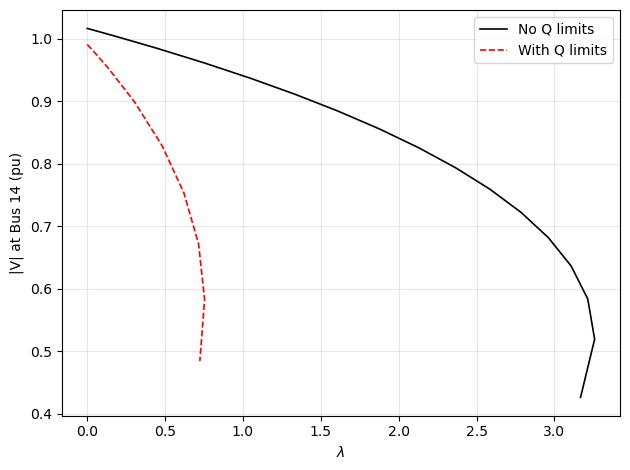

In [21]:
weak_noq = np.argmax(ss_noq.CPF.V[:, 0] - ss_noq.CPF.V[:, np.argmax(ss_noq.CPF.lam)])

fig, ax = plt.subplots()
ax.plot(ss_noq.CPF.lam, ss_noq.CPF.V[weak_noq, :], 'k-', linewidth=1.2, label='No Q limits')
ax.plot(ss_qlim.CPF.lam, ss_qlim.CPF.V[weak_noq, :], 'r--', linewidth=1.2, label='With Q limits')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(f'|V| at Bus {ss_noq.Bus.idx.v[weak_noq]} (pu)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Cleanup

In [22]:
!andes misc -C

"/home/hcui9/repos/andes/docs/source/tutorials/ieee14_out.txt" removed.


## Next Steps

- {doc}`12-state-estimation`: State estimation with WLS and custom measurements
- {doc}`07-eigenvalue-analysis`: Small-signal stability assessment